# 앙상블 가중치 최적화
Team 반갑다모 | 2026.07.01

> Optuna 튜닝된 LightGBM + XGBoost + CatBoost
> 가중치 최적화로 최종 성능 극대화

---

### 전략
| 모델 | 역할 |
|------|------|
| LightGBM (튜닝됨) | 주력 모델 — 단일 최고 성능 |
| XGBoost (순정) | 보조 모델 |
| CatBoost (순정) | 보조 모델 |

- Soft Voting: 각 모델 확률값에 가중치 적용 후 평균
- 가중치 탐색: Optuna로 최적 가중치 자동 탐색


## 0. 환경 설정

In [1]:
import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr
from collections import Counter
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
print('환경 설정 완료')

C:\miniconda\envs\qaqc_st\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


환경 설정 완료


## 1. 데이터 로드 & 피처 선택 (top_n=60)

In [2]:
a31 = pd.read_csv('A_31_preprocessed.csv', low_memory=False)
t31 = pd.read_csv('TO_31_preprocessed.csv', low_memory=False)

DROP_COLS = ['PRODUCT_ID', 'Y_Class', 'Y_Quality', 'TIMESTAMP', 'PRODUCT_CODE']

def get_XY(df):
    feat_cols = [c for c in df.columns if c not in DROP_COLS]
    return df[feat_cols], df['Y_Class'], df['Y_Quality']

X_a, y_a_cls, y_a_qlt = get_XY(a31)
X_t, y_t_cls, y_t_qlt = get_XY(t31)

def select_features(X, y_qlt, top_n=60):
    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    feat_cols = [c for c in X_imp.columns if c.startswith('X_')]
    X_feat = X_imp[feat_cols]
    sp_scores = {}
    for col in feat_cols:
        try:
            r, p = spearmanr(X_feat[col], y_qlt)
            if p < 0.05: sp_scores[col] = abs(r)
        except: pass
    sp_set = set([f for f, _ in sorted(sp_scores.items(), key=lambda x: -x[1])[:top_n]])
    mi_scores = mutual_info_regression(X_feat, y_qlt, random_state=42)
    mi_df = pd.DataFrame({'feature': feat_cols, 'mi': mi_scores})
    mi_set = set(mi_df.sort_values('mi', ascending=False).head(top_n)['feature'])
    scaler = StandardScaler()
    lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
    lasso.fit(scaler.fit_transform(X_feat), y_qlt)
    lasso_coef = pd.Series(np.abs(lasso.coef_), index=feat_cols)
    lasso_set = set(lasso_coef[lasso_coef > 0].index)
    count = Counter([f for s in [sp_set, mi_set, lasso_set] for f in s])
    final_x = [f for f, c in count.items() if c >= 2]
    non_x = [c for c in X_imp.columns if not c.startswith('X_')]
    return final_x + non_x

print('A_31 피처 선택 중...')
selected_a = select_features(X_a, y_a_qlt)
print('T_31 피처 선택 중...')
selected_t = select_features(X_t, y_t_qlt)

X_a_sel = X_a[[c for c in selected_a if c in X_a.columns]]
X_t_sel = X_t[[c for c in selected_t if c in X_t.columns]]
print(f'A_31: {X_a_sel.shape} | T_31: {X_t_sel.shape}')

A_31 피처 선택 중...


T_31 피처 선택 중...


A_31: (316, 34) | T_31: (592, 25)


---
## 2. Optuna 최적 파라미터 입력

> 08_optuna_tuning.ipynb 결과에서 복사해서 넣으세요


In [3]:
# ※ 08_optuna_tuning 결과의 study_a.best_params / study_t.best_params 값으로 교체
# Optuna 08번 노트북 결과 반영
BEST_PARAMS_A = {
    'n_estimators': 549,
    'learning_rate': 0.1854511994787191,
    'num_leaves': 63,
    'max_depth': 12,
    'min_child_samples': 5,
    'subsample': 0.7509101996904098,
    'colsample_bytree': 0.7078633987472305,
    'reg_alpha': 2.226143160389769e-05,
    'reg_lambda': 5.754199315187916e-05,
}

BEST_PARAMS_T = {
    'n_estimators': 689,
    'learning_rate': 0.0484799335027455,
    'num_leaves': 26,
    'max_depth': 11,
    'min_child_samples': 11,
    'subsample': 0.658691796077382,
    'colsample_bytree': 0.5047523197804317,
    'reg_alpha': 0.010328743921014724,
    'reg_lambda': 1.2558834150254984e-08,
}
print('파라미터 설정 완료')
print('※ 08_optuna_tuning의 study.best_params 결과로 위 값을 교체하세요!')

파라미터 설정 완료
※ 08_optuna_tuning의 study.best_params 결과로 위 값을 교체하세요!


---
## 3. 각 모델 OOF 확률값 추출

앙상블을 위해 각 모델의 클래스별 확률값(predict_proba)을 추출


In [4]:
def get_oof_proba(X, y, model_fn, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    proba = np.zeros((len(y), 3))
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = model_fn()
        model.fit(X_tr, y_tr)
        proba[val_idx] = model.predict_proba(X_val)
    return proba

# XGBoost 클래스 가중치 계산 함수
def xgb_sample_weight(y_tr):
    classes = sorted(y_tr.unique())
    counts = y_tr.value_counts()
    return y_tr.map(lambda c: len(y_tr) / (len(classes) * counts[c]))

print('=== A_31 모델별 OOF 확률값 추출 ===')

# LightGBM (튜닝됨)
print('LightGBM...')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_lgb_a = np.zeros((len(y_a_cls), 3))
for tr_idx, val_idx in skf.split(X_a_sel, y_a_cls):
    X_tr, X_val = X_a_sel.iloc[tr_idx], X_a_sel.iloc[val_idx]
    y_tr, y_val = y_a_cls.iloc[tr_idx], y_a_cls.iloc[val_idx]
    m = lgb.LGBMClassifier(**BEST_PARAMS_A, class_weight={0:4,1:1,2:4},
                           random_state=42, verbose=-1)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    proba_lgb_a[val_idx] = m.predict_proba(X_val)

# XGBoost
print('XGBoost...')
proba_xgb_a = np.zeros((len(y_a_cls), 3))
for tr_idx, val_idx in skf.split(X_a_sel, y_a_cls):
    X_tr, X_val = X_a_sel.iloc[tr_idx], X_a_sel.iloc[val_idx]
    y_tr, y_val = y_a_cls.iloc[tr_idx], y_a_cls.iloc[val_idx]
    sw = xgb_sample_weight(y_tr)
    m = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                           random_state=42, eval_metric='mlogloss',
                           early_stopping_rounds=50, verbosity=0)
    m.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_val, y_val)], verbose=False)
    proba_xgb_a[val_idx] = m.predict_proba(X_val)

# CatBoost
print('CatBoost...')
proba_cat_a = np.zeros((len(y_a_cls), 3))
for tr_idx, val_idx in skf.split(X_a_sel, y_a_cls):
    X_tr, X_val = X_a_sel.iloc[tr_idx], X_a_sel.iloc[val_idx]
    y_tr, y_val = y_a_cls.iloc[tr_idx], y_a_cls.iloc[val_idx]
    m = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                           auto_class_weights='Balanced', random_seed=42,
                           verbose=0, early_stopping_rounds=50)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    proba_cat_a[val_idx] = m.predict_proba(X_val)

print('A_31 완료!')

print('\n=== T_31+O_31 모델별 OOF 확률값 추출 ===')

proba_lgb_t = np.zeros((len(y_t_cls), 3))
print('LightGBM...')
for tr_idx, val_idx in skf.split(X_t_sel, y_t_cls):
    X_tr, X_val = X_t_sel.iloc[tr_idx], X_t_sel.iloc[val_idx]
    y_tr, y_val = y_t_cls.iloc[tr_idx], y_t_cls.iloc[val_idx]
    m = lgb.LGBMClassifier(**BEST_PARAMS_T, class_weight='balanced',
                           random_state=42, verbose=-1)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    proba_lgb_t[val_idx] = m.predict_proba(X_val)

proba_xgb_t = np.zeros((len(y_t_cls), 3))
print('XGBoost...')
for tr_idx, val_idx in skf.split(X_t_sel, y_t_cls):
    X_tr, X_val = X_t_sel.iloc[tr_idx], X_t_sel.iloc[val_idx]
    y_tr, y_val = y_t_cls.iloc[tr_idx], y_t_cls.iloc[val_idx]
    sw = xgb_sample_weight(y_tr)
    m = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                           random_state=42, eval_metric='mlogloss',
                           early_stopping_rounds=50, verbosity=0)
    m.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_val, y_val)], verbose=False)
    proba_xgb_t[val_idx] = m.predict_proba(X_val)

proba_cat_t = np.zeros((len(y_t_cls), 3))
print('CatBoost...')
for tr_idx, val_idx in skf.split(X_t_sel, y_t_cls):
    X_tr, X_val = X_t_sel.iloc[tr_idx], X_t_sel.iloc[val_idx]
    y_tr, y_val = y_t_cls.iloc[tr_idx], y_t_cls.iloc[val_idx]
    m = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                           auto_class_weights='Balanced', random_seed=42,
                           verbose=0, early_stopping_rounds=50)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    proba_cat_t[val_idx] = m.predict_proba(X_val)

print('T_31 완료!')

=== A_31 모델별 OOF 확률값 추출 ===
LightGBM...


XGBoost...


CatBoost...


A_31 완료!

=== T_31+O_31 모델별 OOF 확률값 추출 ===
LightGBM...


XGBoost...


CatBoost...


T_31 완료!


---
## 4. Optuna 가중치 최적화

세 모델의 가중치 (w_lgb, w_xgb, w_cat) 합이 1이 되도록 탐색


In [5]:
def optimize_weights(proba_lgb, proba_xgb, proba_cat, y, label, n_trials=100):
    print(f'\n[{label}] 가중치 최적화 중...')

    def objective(trial):
        w_lgb = trial.suggest_float('w_lgb', 0.1, 0.8)
        w_xgb = trial.suggest_float('w_xgb', 0.1, 0.8)
        w_cat = 1.0 - w_lgb - w_xgb
        if w_cat < 0.05:
            return 0.0
        avg = w_lgb*proba_lgb + w_xgb*proba_xgb + w_cat*proba_cat
        pred = np.argmax(avg, axis=1)
        return f1_score(y, pred, average='macro')

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    w_lgb = study.best_params['w_lgb']
    w_xgb = study.best_params['w_xgb']
    w_cat = 1.0 - w_lgb - w_xgb

    print(f'  최적 가중치: LGB={w_lgb:.3f} | XGB={w_xgb:.3f} | CAT={w_cat:.3f}')
    print(f'  최적 F1: {study.best_value:.4f}')

    # 최적 가중치로 최종 예측
    avg = w_lgb*proba_lgb + w_xgb*proba_xgb + w_cat*proba_cat
    pred = np.argmax(avg, axis=1)
    f1 = f1_score(y, pred, average='macro')
    r0 = recall_score(y, pred, labels=[0], average='macro')
    r2 = recall_score(y, pred, labels=[2], average='macro')
    print(f'  Macro F1      : {f1:.4f}')
    print(f'  Class 0 Recall: {r0:.4f}')
    print(f'  Class 2 Recall: {r2:.4f}')

    return pred, {'w_lgb':w_lgb,'w_xgb':w_xgb,'w_cat':w_cat}, \
           {'macro_f1':f1,'recall_0':r0,'recall_2':r2}

pred_a, weights_a, res_a = optimize_weights(
    proba_lgb_a, proba_xgb_a, proba_cat_a, y_a_cls, 'A_31')
pred_t, weights_t, res_t = optimize_weights(
    proba_lgb_t, proba_xgb_t, proba_cat_t, y_t_cls, 'T_31+O_31')


[A_31] 가중치 최적화 중...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0:   0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0:   1%|          | 1/100 [00:00<00:00, 282.88it/s]

Best trial: 2. Best value: 0.759323:   2%|▏         | 2/100 [00:00<00:00, 221.29it/s]

...

Best trial: 76. Best value: 0.686235:  97%|█████████▋| 97/100 [00:00<00:00, 114.02it/s]

Best trial: 76. Best value: 0.686235:  98%|█████████▊| 98/100 [00:00<00:00, 114.02it/s]

Best trial: 76. Best value: 0.686235:  99%|█████████▉| 99/100 [00:00<00:00, 114.02it/s]

Best trial: 76. Best value: 0.686235: 100%|██████████| 100/100 [00:00<00:00, 110.88it/s]

  최적 가중치: LGB=0.700 | XGB=0.230 | CAT=0.070
  최적 F1: 0.6862
  Macro F1      : 0.6862
  Class 0 Recall: 0.5208
  Class 2 Recall: 0.4444


---
## 5. 전체 과정 최종 성능 비교

In [6]:
print('=' * 65)
print('전체 과정 최종 성능 비교')
print('=' * 65)

stages = {
    'A_31': [
        ('Baseline 순정',    0.6995, 0.6711, 0.7111),
        ('피처선택 top60',   0.7211, 0.7237, 0.8444),
        ('Optuna 튜닝',      0.7673, 0.7632, 0.8333),
        ('앙상블 최적화',    res_a['macro_f1'], res_a['recall_0'], res_a['recall_2']),
    ],
    'T_31+O_31': [
        ('Baseline 순정',    0.6303, 0.3750, 0.3519),
        ('피처선택 top60',   0.6579, 0.5417, 0.4630),
        ('Optuna 튜닝',      0.6937, 0.5000, 0.5000),
        ('앙상블 최적화',    res_t['macro_f1'], res_t['recall_0'], res_t['recall_2']),
    ]
}

for product, data in stages.items():
    print(f'\n[{product}]')
    print(f"  {'단계':15} {'Macro F1':>10} {'Class0 Recall':>14} {'Class2 Recall':>14}")
    print(f"  {'-'*57}")
    for stage, f1, r0, r2 in data:
        mark = ' <<' if stage == '앙상블 최적화' else ''
        print(f'  {stage:15} {f1:>10.4f} {r0:>14.4f} {r2:>14.4f}{mark}')

print(f'\n최적 앙상블 가중치:')
print(f'  A_31     : LGB={weights_a["w_lgb"]:.3f} | XGB={weights_a["w_xgb"]:.3f} | CAT={1-weights_a["w_lgb"]-weights_a["w_xgb"]:.3f}')
print(f'  T_31+O_31: LGB={weights_t["w_lgb"]:.3f} | XGB={weights_t["w_xgb"]:.3f} | CAT={1-weights_t["w_lgb"]-weights_t["w_xgb"]:.3f}')

전체 과정 최종 성능 비교

[A_31]
  단계                Macro F1  Class0 Recall  Class2 Recall
  ---------------------------------------------------------
  Baseline 순정         0.6995         0.6711         0.7111
  피처선택 top60          0.7211         0.7237         0.8444
  Optuna 튜닝           0.7673         0.7632         0.8333
  앙상블 최적화             0.7690         0.7368         0.8333 <<

[T_31+O_31]
  단계                Macro F1  Class0 Recall  Class2 Recall
  ---------------------------------------------------------
  Baseline 순정         0.6303         0.3750         0.3519
  피처선택 top60          0.6579         0.5417         0.4630
  Optuna 튜닝           0.6937         0.5000         0.5000
  앙상블 최적화             0.6862         0.5208         0.4444 <<

최적 앙상블 가중치:
  A_31     : LGB=0.421 | XGB=0.483 | CAT=0.096
  T_31+O_31: LGB=0.700 | XGB=0.230 | CAT=0.070


---
## 6. 시각화

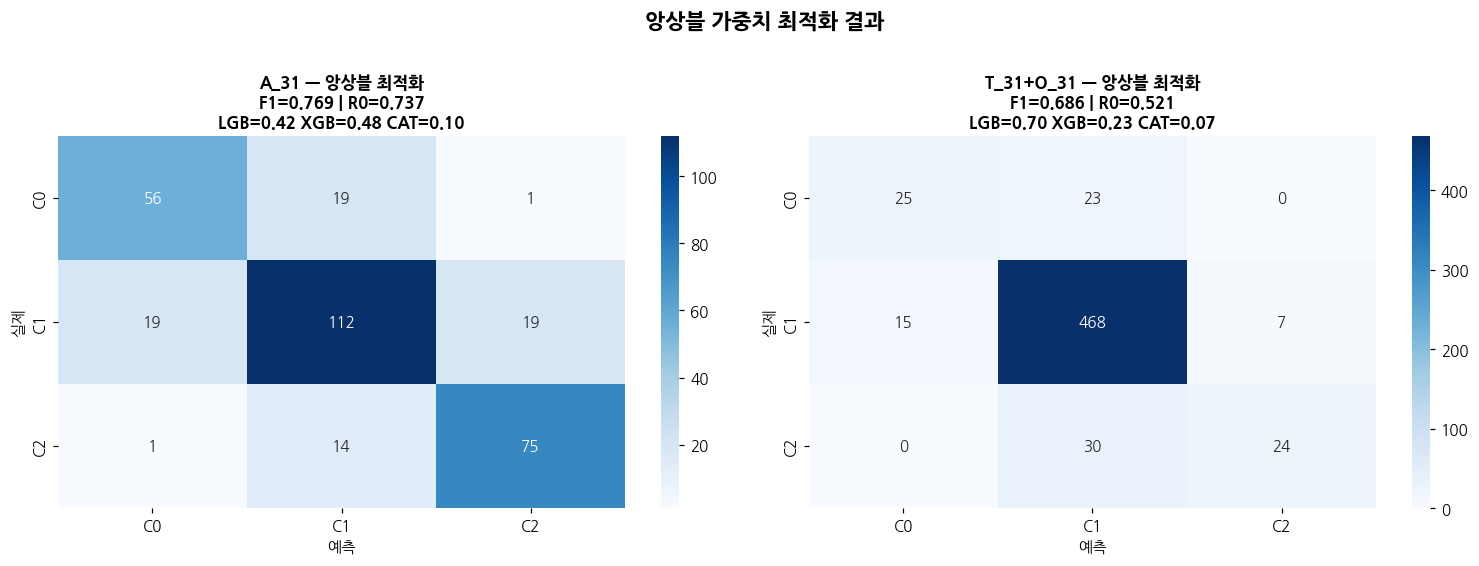

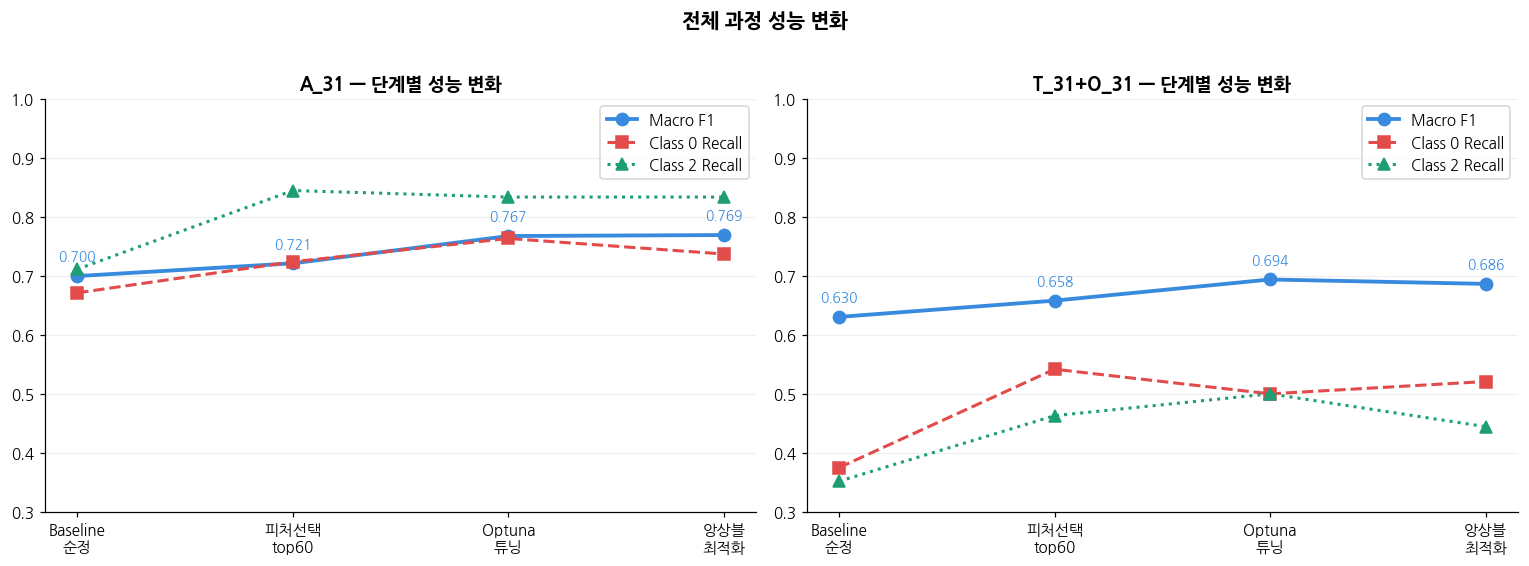

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
for ax, (product, y, pred) in zip(axes, [
    ('A_31', y_a_cls, pred_a),
    ('T_31+O_31', y_t_cls, pred_t)
]):
    res = res_a if 'A' in product else res_t
    weights = weights_a if 'A' in product else weights_t
    w_cat = 1 - weights['w_lgb'] - weights['w_xgb']
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['C0','C1','C2'],
                yticklabels=['C0','C1','C2'])
    ax.set_title(
        f'{product} — 앙상블 최적화\n'
        f'F1={res["macro_f1"]:.3f} | R0={res["recall_0"]:.3f}\n'
        f'LGB={weights["w_lgb"]:.2f} XGB={weights["w_xgb"]:.2f} CAT={w_cat:.2f}',
        fontsize=11, fontweight='bold')
    ax.set_ylabel('실제')
    ax.set_xlabel('예측')

plt.suptitle('앙상블 가중치 최적화 결과', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 단계별 성능 변화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stage_names = ['Baseline\n순정', '피처선택\ntop60', 'Optuna\n튜닝', '앙상블\n최적화']

for ax, (product, data) in zip(axes, stages.items()):
    f1s = [d[1] for d in data]
    r0s = [d[2] for d in data]
    r2s = [d[3] for d in data]
    x = range(len(data))
    ax.plot(x, f1s, 'o-', color='#378ADD', linewidth=2.5, markersize=8, label='Macro F1')
    ax.plot(x, r0s, 's--', color='#E24B4A', linewidth=2, markersize=8, label='Class 0 Recall')
    ax.plot(x, r2s, '^:', color='#1D9E75', linewidth=2, markersize=8, label='Class 2 Recall')
    for i, (f1, r0, r2) in enumerate(zip(f1s, r0s, r2s)):
        ax.annotate(f'{f1:.3f}', (i, f1), textcoords='offset points',
                    xytext=(0,10), ha='center', fontsize=9, color='#378ADD')
    ax.set_xticks(x)
    ax.set_xticklabels(stage_names, fontsize=10)
    ax.set_ylim(0.3, 1.0)
    ax.set_title(f'{product} — 단계별 성능 변화', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('전체 과정 성능 변화', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. 인사이트 & 다음 단계

In [8]:
print('=' * 55)
print('앙상블 최종 인사이트')
print('=' * 55)

for product, res, optuna_f1 in [
    ('A_31', res_a, 0.7673),
    ('T_31+O_31', res_t, 0.6937)
]:
    diff = res['macro_f1'] - optuna_f1
    print(f'\n[{product}]')
    print(f'  Optuna 튜닝: {optuna_f1:.4f} -> 앙상블: {res["macro_f1"]:.4f} ({diff:+.4f})')
    if diff > 0.005:
        print('  -> 앙상블 효과 있음!')
    elif diff >= 0:
        print('  -> 소폭 개선')
    else:
        print('  -> LightGBM 단독이 더 나음. LightGBM만 사용 권장')

print('\n' + '=' * 55)
print('다음 단계')
print('=' * 55)
print('  -> SHAP 분석 (H1~H4 가설 검증)')

앙상블 최종 인사이트

[A_31]
  Optuna 튜닝: 0.7673 -> 앙상블: 0.7690 (+0.0017)
  -> 소폭 개선

[T_31+O_31]
  Optuna 튜닝: 0.6937 -> 앙상블: 0.6862 (-0.0075)
  -> LightGBM 단독이 더 나음. LightGBM만 사용 권장

다음 단계
  -> SHAP 분석 (H1~H4 가설 검증)
